# WAV Dataset Waveform Analysis for wav2vec2 Fine-Tuning

This notebook scans the dataset CSV, resolves each WAV file, and computes waveform-focused statistics that are useful before fine-tuning wav2vec2.

The analysis prioritizes duration, sample rate, channel count, peak amplitude, RMS energy, clipping, silence ratio, and zero-crossing rate.

In [1]:
from pathlib import Path
import wave
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [3]:
# Dataset configuration
csv_path = Path("../notebooks/finetune-wav2vec2/train_set/train.csv")
audio_dir = Path("../notebooks/finetune-wav2vec2/train_set/wavs")
path_col = "path"

# Waveform quality thresholds
silence_threshold = 0.02
clip_threshold = 0.98

# Optional limit for quick experiments. Set to None to scan the full dataset.
limit = None

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

print(f"CSV path: {csv_path.resolve()}")
print(f"Audio directory: {audio_dir.resolve()}")

CSV path: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\finetune-wav2vec2\train_set\train.csv
Audio directory: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\finetune-wav2vec2\train_set\wavs


In [4]:
def resolve_audio_path(rel_path: str) -> Path | None:
    candidate_paths = [
        audio_dir / Path(rel_path).name,
        csv_path.parent / rel_path,
        Path(rel_path),
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            return candidate
    return None

def pcm_bytes_to_float(buffer: bytes, sample_width: int) -> np.ndarray:
    if sample_width == 1:
        samples = np.frombuffer(buffer, dtype=np.uint8).astype(np.float32)
        return (samples - 128.0) / 128.0
    if sample_width == 2:
        return np.frombuffer(buffer, dtype="<i2").astype(np.float32) / 32768.0
    if sample_width == 3:
        raw = np.frombuffer(buffer, dtype=np.uint8)
        if raw.size % 3 != 0:
            raise ValueError("Invalid 24-bit PCM buffer length")
        raw = raw.reshape(-1, 3).astype(np.int32)
        signed = raw[:, 0] | (raw[:, 1] << 8) | (raw[:, 2] << 16)
        sign_bit = 1 << 23
        signed = (signed ^ sign_bit) - sign_bit
        return signed.astype(np.float32) / float(1 << 23)
    if sample_width == 4:
        return np.frombuffer(buffer, dtype="<i4").astype(np.float32) / 2147483648.0
    raise ValueError(f"Unsupported sample width: {sample_width}")

def zero_crossing_rate(waveform: np.ndarray) -> float:
    if waveform.size < 2:
        return 0.0
    signs = np.signbit(waveform)
    return float(np.mean(signs[1:] != signs[:-1]))

def read_wav_stats(file_path: Path) -> dict:
    with wave.open(str(file_path), "rb") as wav_file:
        channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        sample_rate = wav_file.getframerate()
        frame_count = wav_file.getnframes()
        frames = wav_file.readframes(frame_count)

    duration = frame_count / float(sample_rate) if sample_rate else None
    samples = pcm_bytes_to_float(frames, sample_width)
    if channels > 1:
        samples = samples.reshape(-1, channels).mean(axis=1)

    if samples.size == 0:
        raise ValueError("Empty waveform")

    abs_samples = np.abs(samples)
    peak = float(abs_samples.max())
    rms = float(np.sqrt(np.mean(np.square(samples))))
    silence_ratio = float(np.mean(abs_samples < silence_threshold))
    clipping_ratio = float(np.mean(abs_samples >= clip_threshold))
    crest_factor = float(peak / rms) if rms > 0 else math.inf

    return {
        "file_path": str(file_path),
        "duration_sec": duration,
        "sample_rate": sample_rate,
        "channels": channels,
        "sample_width_bytes": sample_width,
        "frame_count": frame_count,
        "peak_amplitude": peak,
        "rms_amplitude": rms,
        "crest_factor": crest_factor,
        "silence_ratio": silence_ratio,
        "clipping_ratio": clipping_ratio,
        "zero_crossing_rate": zero_crossing_rate(samples),
    }

In [5]:
df = pd.read_csv(csv_path)
if path_col not in df.columns:
    raise KeyError(f"Column '{path_col}' not found. Available columns: {list(df.columns)}")

if limit is not None:
    df = df.head(limit).copy()

records = []
missing_files = []
read_errors = []

for index, row in enumerate(df.itertuples(index=False), start=1):
    rel_path = getattr(row, path_col)
    resolved_path = resolve_audio_path(rel_path)

    if resolved_path is None:
        missing_files.append(rel_path)
        continue

    try:
        stats = read_wav_stats(resolved_path)
        stats["source_path"] = rel_path
        stats["resolved_path"] = str(resolved_path)
        records.append(stats)
    except Exception as exc:
        read_errors.append({"source_path": rel_path, "resolved_path": str(resolved_path), "error": str(exc)})

    if index % 500 == 0 or index == len(df):
        print(f"Processed {index}/{len(df)} rows | ok={len(records)} | missing={len(missing_files)} | errors={len(read_errors)}")

stats_df = pd.DataFrame(records)
errors_df = pd.DataFrame(read_errors)

print(f"Rows in CSV: {len(df)}")
print(f"Processed WAV files: {len(stats_df)}")
print(f"Missing files: {len(missing_files)}")
print(f"Read errors: {len(errors_df)}")

stats_df.head()

Processed 500/3047 rows | ok=500 | missing=0 | errors=0
Processed 1000/3047 rows | ok=1000 | missing=0 | errors=0
Processed 1500/3047 rows | ok=1500 | missing=0 | errors=0
Processed 2000/3047 rows | ok=2000 | missing=0 | errors=0
Processed 2500/3047 rows | ok=2500 | missing=0 | errors=0
Processed 3000/3047 rows | ok=3000 | missing=0 | errors=0
Processed 3047/3047 rows | ok=3047 | missing=0 | errors=0
Rows in CSV: 3047
Processed WAV files: 3047
Missing files: 0
Read errors: 0


,file_path,duration_sec,sample_rate,channels,sample_width_bytes,frame_count,peak_amplitude,rms_amplitude,crest_factor,silence_ratio,clipping_ratio,zero_crossing_rate,source_path,resolved_path
0,..\notebooks\finetune-wav2vec2\train_set\wavs\...,14.058438,16000,1,2,224935,0.970612,0.159282,6.093670,0.445907,0.000000,0.077120,../raw_data/wavs/voice-0001.wav,..\notebooks\finetune-wav2vec2\train_set\wavs\...
1,..\notebooks\finetune-wav2vec2\train_set\wavs\...,13.197688,16000,1,2,211163,0.999969,0.157102,6.365110,0.370562,0.000024,0.073564,../raw_data/wavs/voice-0002.wav,..\notebooks\finetune-wav2vec2\train_set\wavs\...
2,..\notebooks\finetune-wav2vec2\train_set\wavs\...,13.440750,16000,1,2,215052,1.000000,0.163726,6.107781,0.433072,0.000037,0.075289,../raw_data/wavs/voice-0003.wav,..\notebooks\finetune-wav2vec2\train_set\wavs\...
3,..\notebooks\finetune-wav2vec2\train_set\wavs\...,10.693437,16000,1,2,171095,0.996948,0.187122,5.327793,0.383571,0.000006,0.088747,../raw_data/wavs/voice-0004.wav,..\notebooks\finetune-wav2vec2\train_set\wavs\...
4,..\notebooks\finetune-wav2vec2\train_set\wavs\...,16.245438,16000,1,2,259927,0.996277,0.176621,5.640760,0.362082,0.000015,0.080434,../raw_data/wavs/voice-0005.wav,..\notebooks\finetune-wav2vec2\train_set\wavs\...


In [6]:
numeric_columns = [
    "duration_sec",
    "sample_rate",
    "channels",
    "sample_width_bytes",
    "peak_amplitude",
    "rms_amplitude",
    "crest_factor",
    "silence_ratio",
    "clipping_ratio",
    "zero_crossing_rate",
]

summary = stats_df[numeric_columns].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
display(summary)

print("Sample rate distribution")
display(stats_df["sample_rate"].value_counts().sort_index())

print("Channel count distribution")
display(stats_df["channels"].value_counts().sort_index())

print("Potential waveform issues")
issue_mask = (stats_df["clipping_ratio"] > 0) | (stats_df["silence_ratio"] > 0.6) | (stats_df["rms_amplitude"] < 0.01)
display(stats_df.loc[issue_mask, ["source_path", "duration_sec", "sample_rate", "channels", "peak_amplitude", "rms_amplitude", "silence_ratio", "clipping_ratio"]].sort_values(["silence_ratio", "clipping_ratio"], ascending=False).head(20))

,count,mean,std,min,50%,90%,95%,99%,max
duration_sec,3047.0,9.752010e+00,3.781528,1.000000,9.280000,14.560000,16.550000,21.830000,30.470000
sample_rate,3047.0,1.600000e+04,0.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
channels,3047.0,1.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
sample_width_bytes,3047.0,2.000000e+00,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
peak_amplitude,3047.0,6.135136e-01,0.142328,0.164032,0.591492,0.841919,0.852722,0.999969,1.000000
rms_amplitude,3047.0,1.015638e-01,0.028826,0.014919,0.104248,0.134305,0.153746,0.176348,0.210889
crest_factor,3047.0,6.381229e+00,1.800659,3.821652,5.833517,8.780477,10.105783,12.857260,29.376730
silence_ratio,3047.0,4.280579e-01,0.099136,0.155574,0.410774,0.588707,0.648617,0.727065,0.870741
clipping_ratio,3047.0,3.289173e-07,0.000003,0.000000,0.000000,0.000000,0.000000,0.000012,0.000065
zero_crossing_rate,3047.0,1.129384e-01,0.029768,0.047500,0.121412,0.144554,0.151333,0.164579,0.242930


Sample rate distribution


sample_rate
16000    3047
Name: count, dtype: int64

Channel count distribution


channels
1    3047
Name: count, dtype: int64

Potential waveform issues


,source_path,duration_sec,sample_rate,channels,peak_amplitude,rms_amplitude,silence_ratio,clipping_ratio
65,../raw_data/wavs/voice-0066.wav,7.224375,16000,1,0.462219,0.016788,0.870741,0.0
50,../raw_data/wavs/voice-0051.wav,7.552750,16000,1,0.464783,0.015821,0.861135,0.0
60,../raw_data/wavs/voice-0061.wav,15.630875,16000,1,0.286743,0.014919,0.858945,0.0
91,../raw_data/wavs/voice-0092.wav,17.535500,16000,1,0.206879,0.016006,0.856987,0.0
68,../raw_data/wavs/voice-0069.wav,12.609750,16000,1,0.230988,0.016052,0.853080,0.0
78,../raw_data/wavs/voice-0079.wav,15.565188,16000,1,0.164032,0.015459,0.845914,0.0
36,../raw_data/wavs/voice-0037.wav,9.260312,16000,1,0.196381,0.017438,0.838457,0.0
35,../raw_data/wavs/voice-0036.wav,25.942000,16000,1,0.271179,0.017190,0.836385,0.0
26,../raw_data/wavs/voice-0027.wav,13.923312,16000,1,0.281097,0.018888,0.826079,0.0
43,../raw_data/wavs/voice-0044.wav,9.851375,16000,1,0.329956,0.018307,0.818794,0.0


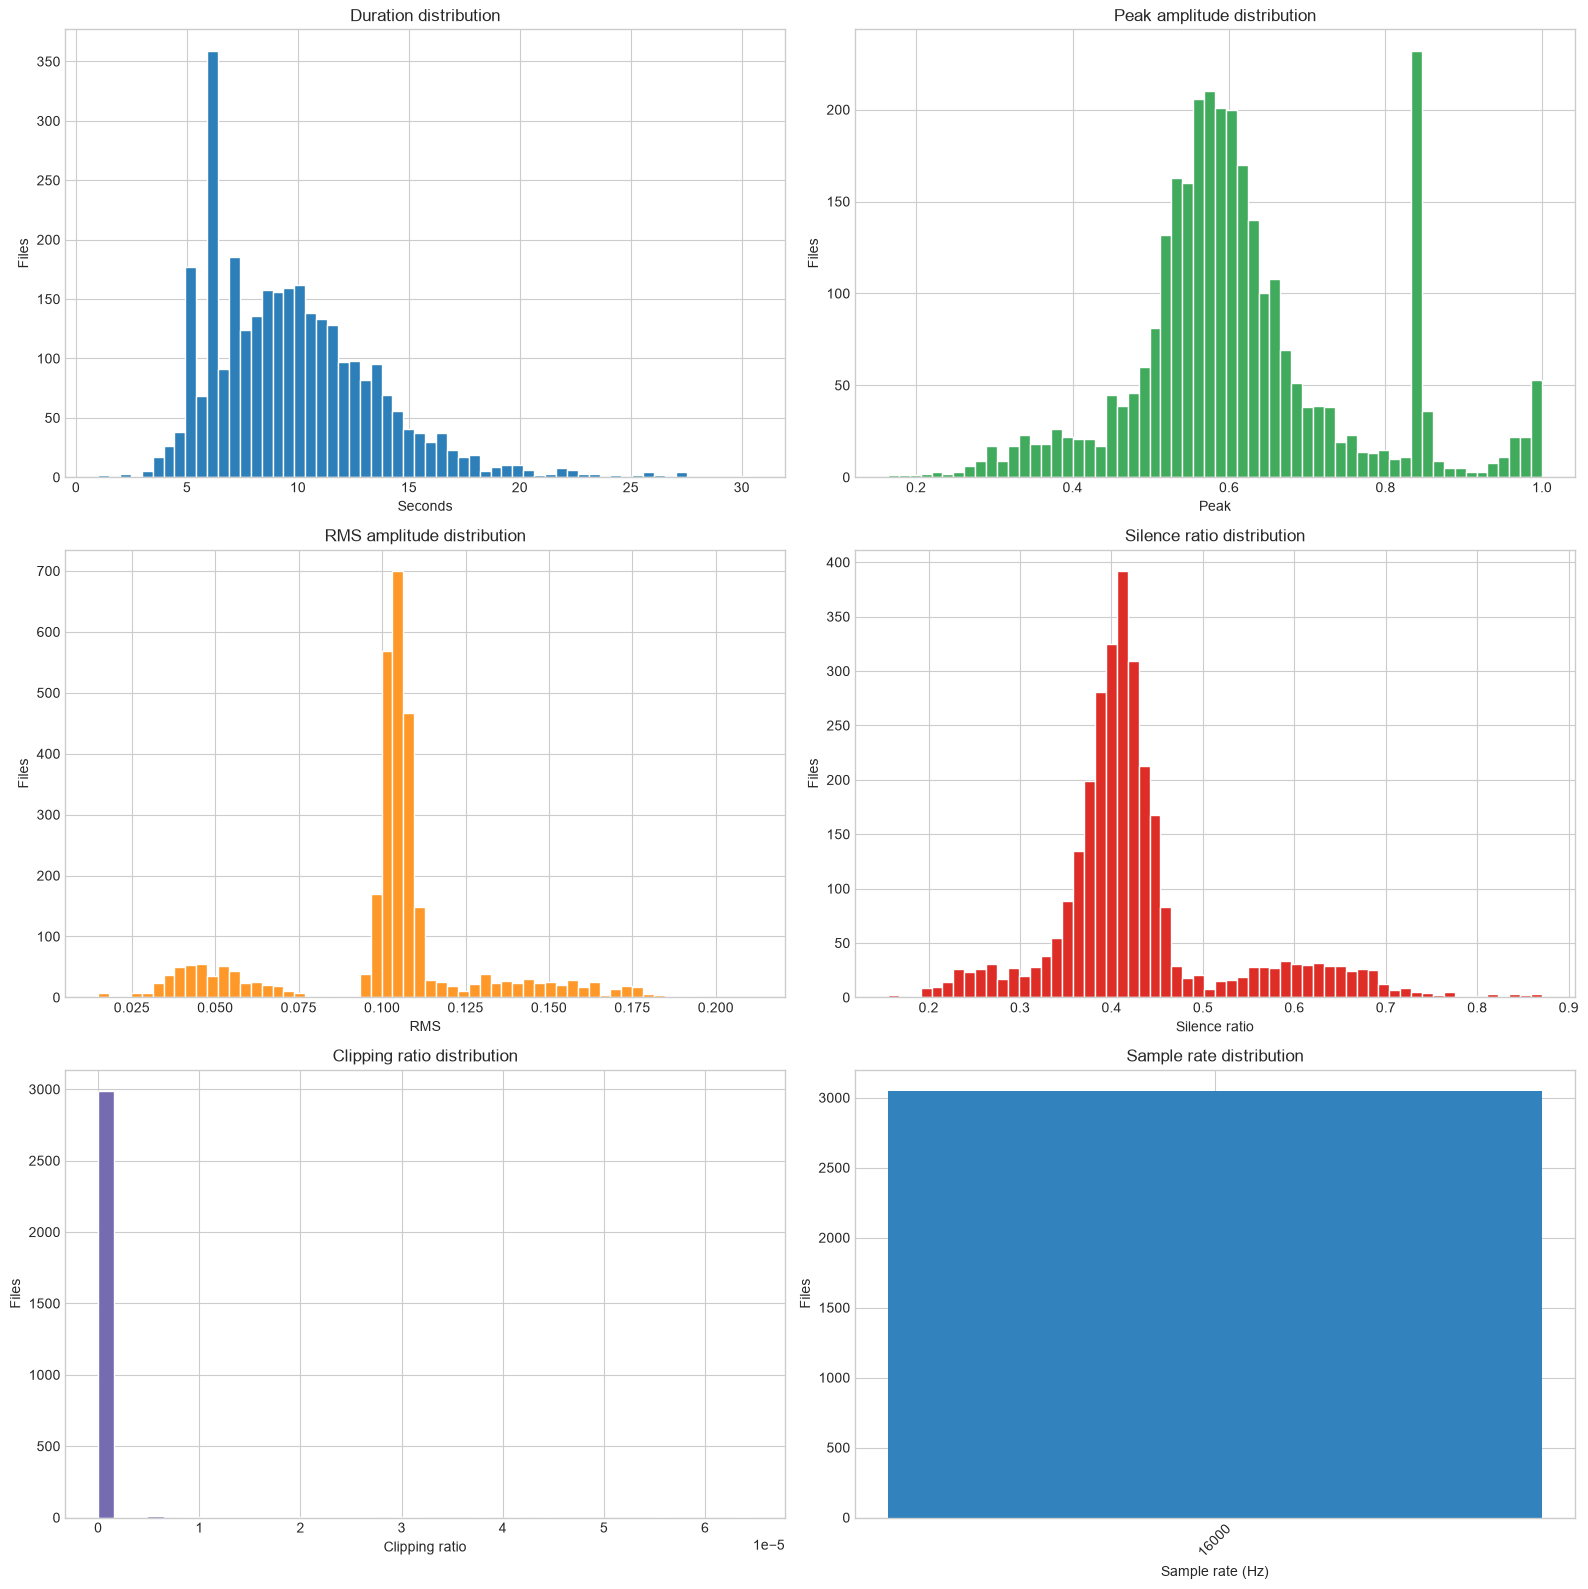

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.ravel()

axes[0].hist(stats_df["duration_sec"], bins=60, color="#2c7fb8", edgecolor="white")
axes[0].set_title("Duration distribution")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Files")

axes[1].hist(stats_df["peak_amplitude"], bins=60, color="#41ab5d", edgecolor="white")
axes[1].set_title("Peak amplitude distribution")
axes[1].set_xlabel("Peak")
axes[1].set_ylabel("Files")

axes[2].hist(stats_df["rms_amplitude"], bins=60, color="#fe9929", edgecolor="white")
axes[2].set_title("RMS amplitude distribution")
axes[2].set_xlabel("RMS")
axes[2].set_ylabel("Files")

axes[3].hist(stats_df["silence_ratio"], bins=60, color="#de2d26", edgecolor="white")
axes[3].set_title("Silence ratio distribution")
axes[3].set_xlabel("Silence ratio")
axes[3].set_ylabel("Files")

axes[4].hist(stats_df["clipping_ratio"], bins=40, color="#756bb1", edgecolor="white")
axes[4].set_title("Clipping ratio distribution")
axes[4].set_xlabel("Clipping ratio")
axes[4].set_ylabel("Files")

sample_rate_counts = stats_df["sample_rate"].value_counts().sort_index()
axes[5].bar(sample_rate_counts.index.astype(str), sample_rate_counts.values, color="#3182bd")
axes[5].set_title("Sample rate distribution")
axes[5].set_xlabel("Sample rate (Hz)")
axes[5].set_ylabel("Files")
axes[5].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [8]:
output_dir = Path("notebooks/waveform_analysis_output")
output_dir.mkdir(parents=True, exist_ok=True)

stats_path = output_dir / "wav2vec2_waveform_stats.csv"
summary_path = output_dir / "wav2vec2_waveform_summary.json"
issues_path = output_dir / "wav2vec2_waveform_issues.csv"
missing_path = output_dir / "wav2vec2_missing_files.txt"
errors_path = output_dir / "wav2vec2_read_errors.csv"

stats_df.to_csv(stats_path, index=False)
summary.to_json(summary_path, orient="index", indent=2)
stats_df.loc[issue_mask].to_csv(issues_path, index=False)
pd.Series(missing_files, name="missing_files").to_csv(missing_path, index=False, header=False)
errors_df.to_csv(errors_path, index=False)

print(f"Saved waveform stats to: {stats_path.resolve()}")
print(f"Saved summary to: {summary_path.resolve()}")
print(f"Saved issues to: {issues_path.resolve()}")
print(f"Saved missing file list to: {missing_path.resolve()}")
print(f"Saved read errors to: {errors_path.resolve()}")

Saved waveform stats to: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\notebooks\waveform_analysis_output\wav2vec2_waveform_stats.csv
Saved summary to: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\notebooks\waveform_analysis_output\wav2vec2_waveform_summary.json
Saved issues to: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\notebooks\waveform_analysis_output\wav2vec2_waveform_issues.csv
Saved missing file list to: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\notebooks\waveform_analysis_output\wav2vec2_missing_files.txt
Saved read errors to: E:\Github\Vietnamese Speech-Based Medical  Consultation System Using ASR and  Conversational AI\notebooks\notebooks\waveform_analysis_output\wav2vec2_read_errors.csv
